In [9]:
import json

DATA_INFO_PATH = "SLEEP/dataset_info.json"

with open(DATA_INFO_PATH, "r", encoding="utf-8") as f:
    info = json.load(f)

category_list = info["dataset"]["category_list"]
channels = info["dataset"]["channels"]
target_sampling_rate = info["processing"]["target_sampling_rate"]
window_sec = info["processing"]["window_sec"]

print("=== Dataset Intro ===")
print("Categories:", category_list)
print("Channels (count):", len(channels))
print("Channels:", channels)
print("Target Sampling Rate (Hz):", target_sampling_rate)
print("Window Size (sec):", window_sec)


=== Dataset Intro ===
Categories: ['Wake', 'N1', 'N2', 'N3', 'REM']
Channels (count): 6
Channels: ['C3_A2', 'C4_A1', 'F3_A2', 'F4_A1', 'O1_A2', 'O2_A1']
Target Sampling Rate (Hz): 200.0
Window Size (sec): 30.0


## 1) 设定数据路径并检查数据形状
这一格会选择数据集（`DATA_NAME`），并读取 `train/val/test` 的基本信息，先确认维度是否符合预期。


In [10]:
import h5py
import numpy as np
DATA_NAME = "SLEEP"
INDEX_PATH_TRAIN = f"{DATA_NAME}/train.h5"
INDEX_PATH_VAL = f"{DATA_NAME}/val.h5"
INDEX_PATH_TEST = f"{DATA_NAME}/test_x_only.h5"

with h5py.File(INDEX_PATH_TRAIN, "r") as f:
    print("keys:", list(f.keys()))
    print("x dtype:", f["X"].dtype)
    print("x shape:", f["X"].shape)
    print("y dtype:", f["y"].dtype)
    print("y shape:", f["y"].shape)
    y = f["y"][()]
    print("unique:", np.unique(y))

keys: ['X', 'y']
x dtype: float32
x shape: (3921, 6, 6000)
y dtype: int64
y shape: (3921,)
unique: [0 1 2 3 4]


## 5) 导入模型
这里希望同学们自己手搓一个RNN代码，试试RNN的训练效果如何


In [11]:

from MultiScaleDeepSleepNet import MultiScaleDeepSleepNet

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.gamma = gamma
        self.reduction = reduction
        # 将 alpha 注册为 buffer，这样它会随模型一起移动到 GPU/CPU
        if alpha is not None:
            self.register_buffer('alpha', alpha)
        else:
            self.alpha = None

    def forward(self, inputs, targets):
        # 这里的 self.alpha 会自动与 inputs 在同一设备上
        ce_loss = F.cross_entropy(inputs, targets, weight=self.alpha, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

## 6) 准备 DataLoader 并训练/验证
这一格完成数据加载、损失函数与优化器设置，然后执行训练循环并记录 `train/val` 指标与曲线。


In [18]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from TEST_DATASET import TrainDataset, TestDataset

# =====================================================================
# 1. 参数与模型初始化配置
# =====================================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_epochs = 50  # 请根据你的实际需求修改总 Epoch 数
batch_size = 64  #

# -------------------------
# 数据
# -------------------------
train_ds = TrainDataset(INDEX_PATH_TRAIN)
val_ds = TrainDataset(INDEX_PATH_VAL)
test_ds = TestDataset(INDEX_PATH_TEST)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=1, shuffle=False)

# 初始化模型 (确保导入了你的 MultiScaleDeepSleepNet)
model = MultiScaleDeepSleepNet(chans=6, num_classes=5, dropout=0.5).to(device) #

# 损失函数：建议开启 label_smoothing=0.1 来配合余弦退火，极大地压制 Loss 突变震荡
criterion = nn.CrossEntropyLoss(label_smoothing=0.1) #

# 优化器：将初始学习率调整为更稳健的 3e-4 (原为 8e-4)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-3, weight_decay=1e-2) #

# 【核心修改点】：改用余弦退火调度器
# T_max 设为总的 Epoch 数，学习率将在 num_epochs 内从 3e-4 丝滑下降到 eta_min (1e-6)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=num_epochs,
    eta_min=3e-5
)

# =====================================================================
# 2. 完整的训练与验证循环 (Training Loop)
# =====================================================================
train_loss_history = []
val_loss_history = []
val_acc_history = []

# 1. 在训练循环开始前，初始化最高准确率
best_val_acc = 0.0
best_model_path = 'best_multi_scale_sleep_net.pth'

print("开始训练（使用余弦退火调度器 + 梯度裁剪）...")

for epoch in range(num_epochs):
    # ------------------ 训练阶段 (Train) ------------------
    model.train()
    running_train_loss = 0.0
    correct_train = 0
    total_train = 0

    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)

        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()

        # 【关键补漏】：调用模型内部的梯度裁剪，稳定 LSTM 层的梯度更新
        if hasattr(model, 'clip_gradients'):
            model.clip_gradients() #
        else:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        # 统计
        running_train_loss += loss.item() * batch_x.size(0)
        preds = torch.argmax(outputs, dim=1)
        correct_train += (preds == batch_y).sum().item()
        total_train += batch_y.size(0)

    epoch_train_loss = running_train_loss / total_train
    epoch_train_acc = correct_train / total_train
    train_loss_history.append(epoch_train_loss)

    # ------------------ 验证阶段 (Validation) ------------------
    model.eval()
    running_val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for val_x, val_y in val_loader:
            val_x, val_y = val_x.to(device), val_y.to(device)
            outputs = model(val_x)
            loss = criterion(outputs, val_y)

            running_val_loss += loss.item() * val_x.size(0)
            preds = torch.argmax(outputs, dim=1)
            correct_val += (preds == val_y).sum().item()
            total_val += val_y.size(0)

    epoch_val_loss = running_val_loss / total_val
    epoch_val_acc = correct_val / total_val
    val_loss_history.append(epoch_val_loss)
    val_acc_history.append(epoch_val_acc)

    val_acc = epoch_val_acc

    # 2. 在每轮验证结束时，加入以下判断
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        # 保存当前表现最好的模型权重
        torch.save(model.state_dict(), best_model_path)
        print(f"=> 并在第 {epoch+1} 轮发现了更好的模型，Val Acc 达到: {val_acc:.4f}，已保存！")

    # 获取当前 Epoch 的学习率用于打印
    current_lr = optimizer.param_groups[0]['lr']

    # 【核心修改点】：余弦退火在每个 Epoch 结束时直接调用 step()，无需传入任何指标参数
    scheduler.step()

    # ------------------ 打印日志 ------------------
    print(f"Epoch [{epoch+1:02d}/{num_epochs:02d}] | "
          f"LR: {current_lr:.6f} | "
          f"Train Loss: {epoch_train_loss:.4f} (Acc: {epoch_train_acc:.4f}) | "
          f"Val Loss: {epoch_val_loss:.4f} (Acc: {epoch_val_acc:.4f})")

print("训练完成！")

print(f"整个训练结束！正在载入历史最高验证集准确率 ({best_val_acc:.4f}) 的模型进行最终测试...")
model.load_state_dict(torch.load(best_model_path))
model.eval()

开始训练（使用余弦退火调度器 + 梯度裁剪）...
=> 并在第 1 轮发现了更好的模型，Val Acc 达到: 0.4364，已保存！
Epoch [01/50] | LR: 0.003000 | Train Loss: 1.4719 (Acc: 0.3486) | Val Loss: 1.3548 (Acc: 0.4364)
=> 并在第 2 轮发现了更好的模型，Val Acc 达到: 0.4930，已保存！
Epoch [02/50] | LR: 0.002997 | Train Loss: 1.3561 (Acc: 0.4438) | Val Loss: 1.2963 (Acc: 0.4930)
=> 并在第 3 轮发现了更好的模型，Val Acc 达到: 0.5389，已保存！
Epoch [03/50] | LR: 0.002988 | Train Loss: 1.2986 (Acc: 0.4999) | Val Loss: 1.2364 (Acc: 0.5389)
=> 并在第 4 轮发现了更好的模型，Val Acc 达到: 0.5811，已保存！
Epoch [04/50] | LR: 0.002974 | Train Loss: 1.2752 (Acc: 0.4966) | Val Loss: 1.1915 (Acc: 0.5811)
Epoch [05/50] | LR: 0.002953 | Train Loss: 1.1788 (Acc: 0.5629) | Val Loss: 1.1674 (Acc: 0.5590)
Epoch [06/50] | LR: 0.002927 | Train Loss: 1.1861 (Acc: 0.5626) | Val Loss: 1.1711 (Acc: 0.5641)
Epoch [07/50] | LR: 0.002896 | Train Loss: 1.1612 (Acc: 0.5766) | Val Loss: 1.1514 (Acc: 0.5533)
=> 并在第 8 轮发现了更好的模型，Val Acc 达到: 0.6028，已保存！
Epoch [08/50] | LR: 0.002859 | Train Loss: 1.1587 (Acc: 0.5861) | Val Loss: 1.09

C:\Users\lenovo\AppData\Local\Temp\ipykernel_29300\1546096670.py:133: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_model_path))


MultiScaleDeepSleepNet(
  (small_branch): Sequential(
    (0): Conv1d(6, 32, kernel_size=(32,), stride=(6,), padding=(24,))
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=8, stride=8, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout(p=0.5, inplace=False)
    (5): Conv1d(32, 64, kernel_size=(8,), stride=(1,), padding=(3,))
    (6): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): ReLU()
    (8): Conv1d(64, 64, kernel_size=(8,), stride=(1,), padding=(3,))
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool1d(kernel_size=4, stride=4, padding=0, dilation=1, ceil_mode=False)
  )
  (large_branch): Sequential(
    (0): Conv1d(6, 32, kernel_size=(512,), stride=(50,), padding=(175,))
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  

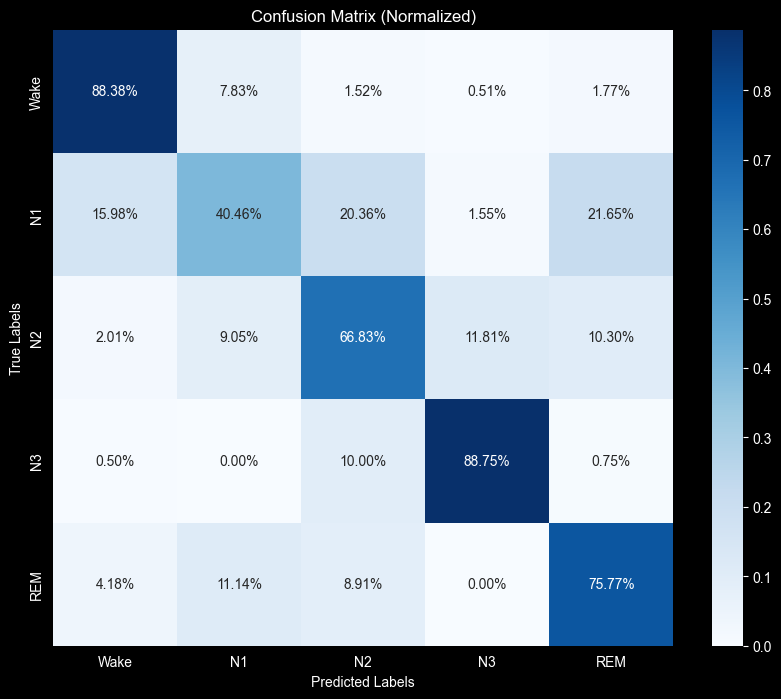

              precision    recall  f1-score   support

        Wake       0.80      0.88      0.84       396
          N1       0.59      0.40      0.48       388
          N2       0.63      0.67      0.65       398
          N3       0.87      0.89      0.88       400
         REM       0.67      0.76      0.71       359

    accuracy                           0.72      1941
   macro avg       0.71      0.72      0.71      1941
weighted avg       0.71      0.72      0.71      1941



In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

def plot_confusion_matrix(model, val_loader, device, classes):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for data, labels in val_loader:
            data = data.to(device)
            outputs = model(data)
            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    # 1. 计算混淆矩阵
    cm = confusion_matrix(all_labels, all_preds)

    # 2. 归一化（显示百分比，更直观）
    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    # 3. 绘图
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm_percent, annot=True, fmt='.2%', cmap='Blues',
                xticklabels=classes, yticklabels=classes)
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.title('Confusion Matrix (Normalized)')
    plt.show()

    # 4. 打印详细报告 (Precision, Recall, F1)
    print(classification_report(all_labels, all_preds, target_names=classes))

# 调用方法（假设你的类别列表如下）
class_names = ['Wake', 'N1', 'N2', 'N3', 'REM']
plot_confusion_matrix(model, val_loader, device, class_names)

## 7) 生成并保存 test 预测标签
使用当前训练好的 `model` 在测试集推理，把预测类别按“每行一个数字”写入文本文件。


In [20]:
from TEST_DATASET import TestDataset
# -------------------------
# 保存 test 预测标签 (已修复设备匹配)
# -------------------------
model.eval()
output_path = f'{DATA_NAME}/{DATA_NAME}.txt'

all_test_labels = []
with torch.no_grad():
    for test_data in test_loader:
        # 【关键修正】：将测试数据搬运到 GPU
        test_data = test_data.to(device)

        test_output = model(test_data)
        test_pred = torch.argmax(test_output, dim=1)

        # 【注意】：取出数据存入列表前，必须先 .cpu() 搬回内存
        all_test_labels.extend(test_pred.cpu().tolist())

with open(output_path, "w", encoding="utf-8") as f:
    for label in all_test_labels:
        f.write(f"{int(label)}\n")

print(f"成功保存 {len(all_test_labels)} 条预测结果至: {output_path}")


成功保存 1945 条预测结果至: SLEEP/SLEEP.txt
